# 04 — 모델 · 앙상블 진단: 학습 결과를 열어 보기

앞의 세 노트북이 **데이터와 피처**를 봤다면, 이 노트북은 **실제 학습 결과**를 연다.
`experiments/baseline/baseline.py` 를 완주하면 저장되는 OOF 예측 배열
(512개 그룹 전체, 262,144행 × 8개 모델)을 그대로 읽어 분석한다.

## 왜 학습이 끝난 뒤에도 분석을 하나

초보자가 가장 많이 건너뛰는 단계가 여기다.
CV 점수를 확인하고 제출하면 끝이라고 생각하기 쉽지만,
**"왜 이 점수가 나왔는지"를 모르면 다음에 무엇을 해야 할지도 모른다.**

이 노트북은 이런 질문에 답한다.
- 모델을 6개나 앙상블했는데 **왜 개별 모델보다 거의 안 좋아졌나?**
- 모델을 하나 더 추가하면 오를까, 아니면 시간 낭비일까?
- 가중치를 학습시키면 오를까?

## OOF 예측이라는 자산

**OOF(Out-Of-Fold) 예측**은 학습이 끝나면 버려지기 쉽지만,
사실 **가장 값진 부산물**이다. 각 행에 대해 "학습에 쓰이지 않은 상태에서의 예측"이 들어 있어서
**모델을 다시 학습시키지 않고도** 앙상블 실험, 오류 분석, 모델 비교를 전부 할 수 있다.

그래서 baseline 은 `.npy` 로 OOF 를 저장한다. 이 노트북은 **몇 초 만에** 512개 그룹의
학습 결과를 분석한다 — 재학습에는 44분이 걸리는데도.

> 💡 **습관으로 만들 것:** 학습 스크립트를 짤 때 항상 OOF 예측을 파일로 저장하라.

## 다루는 질문
1. 6개 모델은 서로 얼마나 다른 예측을 하는가 — 앙상블할 가치가 있는가?
2. 모델별 확률 예측은 어떤 모양인가?
3. **pooled AUC 와 그룹별 AUC 평균은 왜 다른가?** (이 노트북의 하이라이트)
4. 그룹별로 잘하는 모델이 다른가?
5. 가중 앙상블을 하면 오르는가? (누수 없이 추정)
6. 어떤 샘플에서 틀리는가?

> 실행 전제: `python experiments/baseline/baseline.py` 를 한 번 완주해
> `experiments/baseline/outputs/baseline_oof_*.npy` 가 있어야 한다.

In [1]:
import json
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy import stats

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, roc_curve

PROJECT_DIR = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "loader.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR))
from data.loader import get_data_dir

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
_available = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

OUTPUT_DIR = PROJECT_DIR / "experiments" / "baseline" / "outputs"
MAGIC_COL = "wheezy-copper-turtle-magic"

# 산출물이 없으면 조용히 실패하지 말고 무엇을 해야 하는지 알려 준다
required = OUTPUT_DIR / "baseline_oof_train_level1.npy"
if not required.exists():
    raise FileNotFoundError(
        f"{required} 가 없습니다.\n"
        "먼저 `python experiments/baseline/baseline.py` 를 실행하세요."
    )
metrics = json.loads((OUTPUT_DIR / "baseline_metrics.json").read_text(encoding="utf-8"))
MODEL_NAMES = metrics["config"]["models"]
print("모델:", MODEL_NAMES)
print("baseline 최종 AUC:", round(metrics["final_auc"], 5))

모델: ['nusvc_deg4', 'nusvc_deg2', 'qda', 'svc_deg4', 'knn16', 'logreg_l1']
baseline 최종 AUC: 0.9496


### 읽어 들이는 것

| 파일 | 내용 |
|---|---|
| `baseline_oof_train_level1.npy` | level-1 모델 6개의 OOF 예측 (262144 × 6) |
| `baseline_oof_train_final.npy` | 위 6열 + LightGBM 메타 + MLP 메타 (262144 × 8) |
| `baseline_metrics.json` | 실행 설정과 기록된 AUC |

정답(`target`)과 그룹(`magic`)만 CSV 에서 읽는다. 1.3GB 를 다 읽을 필요가 없다.

In [2]:
oof_l1 = np.load(OUTPUT_DIR / "baseline_oof_train_level1.npy")     # (262144, 6)
oof_final = np.load(OUTPUT_DIR / "baseline_oof_train_final.npy")   # (262144, 8)

# usecols 로 두 컬럼만 읽는다 (1.3GB 전체를 읽지 않음)
labels = pd.read_csv(get_data_dir() / "train.csv", usecols=["target", MAGIC_COL])
y = labels["target"].to_numpy()
magic = labels[MAGIC_COL].to_numpy()
del labels

oof = pd.DataFrame(oof_l1, columns=MODEL_NAMES)
oof["lgbm_meta"] = oof_final[:, 6]     # level-2 메타 모델 2개를 마지막 두 열에서 꺼낸다
oof["mlp_meta"] = oof_final[:, 7]
ALL_COLS = list(oof.columns)

auc_table = pd.Series({c: roc_auc_score(y, oof[c]) for c in ALL_COLS}).sort_values(ascending=False)
print(f"OOF 배열: {oof.shape}, 양성 비율 {y.mean():.4f}")
print()
print("개별 AUC:")
print(auc_table.round(5).to_string())

OOF 배열: (262144, 8), 양성 비율 0.5000

개별 AUC:
mlp_meta      0.94996
logreg_l1     0.94977
knn16         0.94971
lgbm_meta     0.94956
svc_deg4      0.94954
nusvc_deg4    0.94954
nusvc_deg2    0.94950
qda           0.94926


> **첫 번째 놀라움.** `logreg_l1` 이 **2위(0.94977)** 다.
>
> [01 노트북](01_eda_report.ipynb) 5절에서 "클래스를 가르는 것은 평균이 아니라 분산 구조이므로
> 선형 모델은 불리하다"고 했고, 실제로 baseline 실행 로그를 보면
> LogisticRegression 은 개별 실행에서 0.938 로 **6개 중 꼴찌**였다.
>
> 그런데 여기서는 2위다. 무슨 일이 일어난 걸까?
> **3절에서 이 수수께끼를 푼다.** (힌트: 지금 보고 있는 값은 4회 실행을 평균낸 것이고,
> 게다가 512개 그룹의 예측을 한 줄로 모아서 잰 값이다)

## 1. 모델은 서로 다른 예측을 하는가?

**무엇을 하나** — 모델 예측들 사이의 상관관계를 잰다.

**왜 하나** — **앙상블이 이득을 보는 조건**을 확인하기 위해서다.

**원리 — 앙상블은 언제 효과가 있나**
앙상블의 이득은 **모델들이 서로 다른 실수를 할 때** 나온다.
A 가 틀린 샘플을 B 가 맞히면, 평균냈을 때 서로 보완된다.
반대로 **모두 같은 샘플에서 틀리면 평균내도 그 샘플은 여전히 틀린다.**

이걸 오차 분해로 보면:
- 모델들이 **완전히 독립**이면 → 평균의 분산이 1/n 로 줄어든다 (큰 이득)
- 모델들이 **완전히 같으면** → 평균해도 그대로 (이득 0)

**왜 상관을 두 종류로 보나**
- **피어슨**: 확률 값 자체의 선형 관계
- **스피어만**: 순위의 관계

AUC 는 **순위만** 보므로, 앙상블의 이득을 예측하는 데는 **스피어만이 더 직접적**이다.

**기대 결과** — 상관이 0.7 이하면 앙상블 이득을 기대할 수 있다.
0.95 이상이면 사실상 같은 모델이라 이득이 거의 없다.

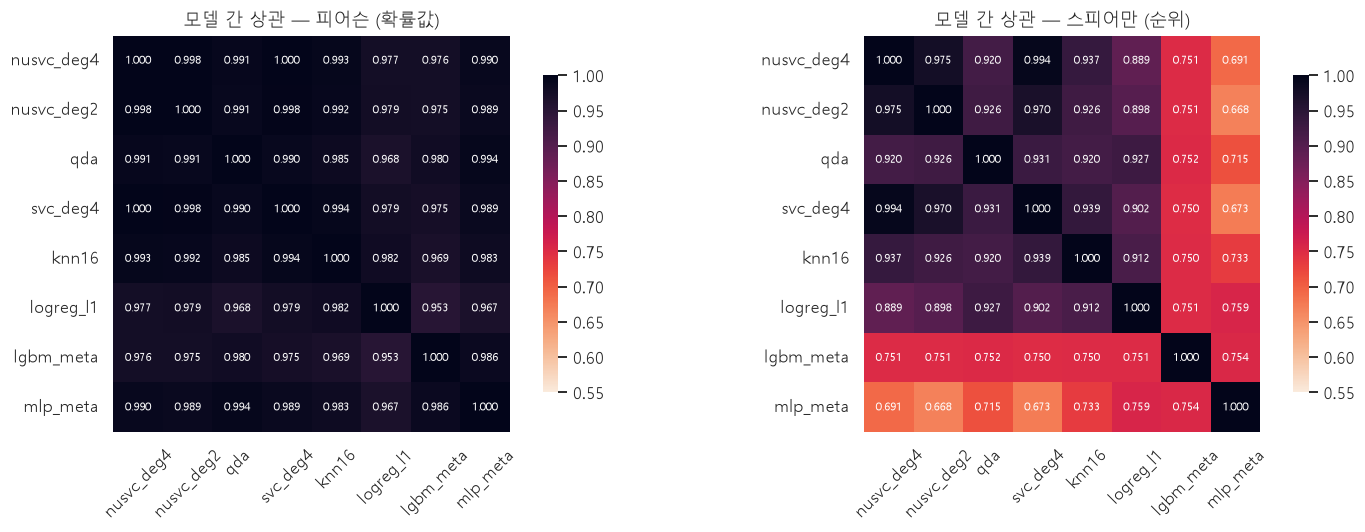

level-1 6개 모델 간 순위상관: 최소 0.889, 평균 0.931, 최대 0.994
가장 다른 조합: nusvc_deg4 vs logreg_l1 (0.889)


In [3]:
# 262,144행 전체로 스피어만 상관을 계산하면 느리다. 무작위 표본 4만 행이면 충분히 정확하다.
SAMPLE = np.random.default_rng(0).choice(len(oof), 40000, replace=False)
pearson = oof.iloc[SAMPLE].corr(method="pearson")
spearman = oof.iloc[SAMPLE].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title in zip(axes, (pearson, spearman), ("피어슨 (확률값)", "스피어만 (순위)")):
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="rocket_r", vmin=0.55, vmax=1.0,
                square=True, ax=ax, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
    ax.set_title(f"모델 간 상관 — {title}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

l1 = spearman.loc[MODEL_NAMES, MODEL_NAMES].to_numpy()
off = l1[np.triu_indices_from(l1, k=1)]      # 상삼각 부분만 = 서로 다른 모델 쌍
print(f"level-1 6개 모델 간 순위상관: 최소 {off.min():.3f}, 평균 {off.mean():.3f}, 최대 {off.max():.3f}")
pair = np.unravel_index(np.argmin(l1 + np.eye(len(l1))), l1.shape)   # 대각선 제외 최솟값
print(f"가장 다른 조합: {MODEL_NAMES[pair[0]]} vs {MODEL_NAMES[pair[1]]} ({l1[pair]:.3f})")

> **관찰 — 앙상블이 안 되는 이유가 여기 있다.**
> level-1 6개 모델의 순위상관이 **0.89 ~ 0.99**, 평균 0.93 이다.
> 가장 다른 조합조차 0.889 — **사실상 같은 예측을 하고 있다.**
>
> ### 왜 이렇게 비슷한가
> 6개 모델(NuSVC×2, QDA, SVC, KNN, LogisticRegression)은 이름은 다르지만
> **전부 "거리와 공분산"에 기반한 모델**이다. 게다가 **똑같은 입력 피처**를 받는다.
> 서로 다른 실수를 할 이유가 없다.
>
> ### 실무적 함의
> **모델을 하나 더 추가해도 소용없다** — 같은 계열이라면.
> 앙상블을 개선하려면 **성격이 근본적으로 다른 모델**(예: 트리 계열)이나
> **다른 전처리를 거친 입력**을 넣어야 한다.
>
> > **초보자에게** — "모델을 많이 넣을수록 앙상블이 좋아진다"는 흔한 오해다.
> > 중요한 건 개수가 아니라 **다양성(diversity)** 이다. 넣기 전에 상관을 먼저 재 보라.

## 2. 확률 보정 (calibration)

**무엇을 하나** — 모델이 "70% 확률"이라고 말한 샘플들이 실제로 70% 비율로 양성인지 확인한다.

**용어 — 보정(calibration)**
예측 확률이 실제 빈도와 일치하는 정도.
잘 보정된 모델은 "p=0.7" 이라고 한 샘플 100개 중 약 70개가 실제 양성이다.

**용어 — Reliability diagram(신뢰도 곡선)**
예측 확률을 구간별로 묶어서 (평균 예측 확률, 실제 양성 비율) 을 그린 그래프.
**대각선에 가까울수록 잘 보정된 것**이다.

**왜 하나 — AUC 만 보면 보정은 중요하지 않은데?**
맞다. **단일 모델**의 AUC 는 순위만 보므로 보정과 무관하다.
하지만 두 곳에서 갑자기 중요해진다.
1. **여러 모델의 확률을 평균낼 때** — 스케일이 다른 확률을 더하면 왜곡이 생긴다
2. **512개 그룹의 예측을 한 줄로 모을 때** — 이게 3절의 주제다

**기대 결과** — 모델마다 확률 분포가 꽤 다를 것이다. 특히 QDA 는 극단으로 치우칠 가능성이 높다.

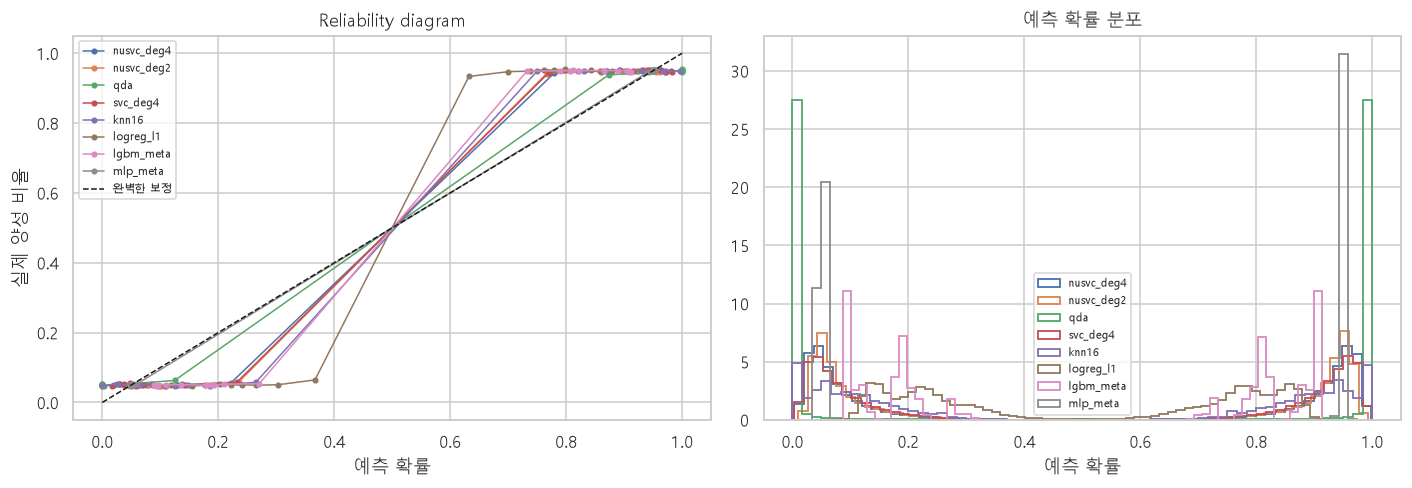

모델별 예측 확률 분포:
               최소   1사분위    중앙값   3사분위     최대   표준편차
nusvc_deg4  0.003  0.058  0.514  0.942  0.998  0.427
nusvc_deg2  0.010  0.063  0.509  0.938  0.993  0.420
qda         0.000  0.000  0.500  1.000  1.000  0.490
svc_deg4    0.002  0.064  0.512  0.937  1.000  0.422
knn16       0.000  0.094  0.516  0.906  1.000  0.408
logreg_l1   0.069  0.213  0.493  0.788  0.936  0.291
lgbm_meta   0.087  0.172  0.577  0.828  0.913  0.349
mlp_meta    0.034  0.050  0.568  0.950  0.974  0.450


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for col in ALL_COLS:
    # strategy="quantile": 각 구간에 같은 수의 샘플이 들어가도록 나눈다
    frac_pos, mean_pred = calibration_curve(y, oof[col], n_bins=20, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, marker="o", ms=3, lw=1, label=col)
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="완벽한 보정")
axes[0].set_xlabel("예측 확률")
axes[0].set_ylabel("실제 양성 비율")
axes[0].set_title("Reliability diagram")
axes[0].legend(fontsize=7)

for col in ALL_COLS:
    axes[1].hist(oof[col], bins=60, histtype="step", lw=1.2, label=col, density=True)
axes[1].set_title("예측 확률 분포")
axes[1].set_xlabel("예측 확률")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

spread = pd.DataFrame({
    "최소": oof[ALL_COLS].min(),
    "1사분위": oof[ALL_COLS].quantile(0.25),
    "중앙값": oof[ALL_COLS].median(),
    "3사분위": oof[ALL_COLS].quantile(0.75),
    "최대": oof[ALL_COLS].max(),
    "표준편차": oof[ALL_COLS].std(),
}).round(3)
print("모델별 예측 확률 분포:")
print(spread.to_string())

> **관찰 — 모델마다 확률의 '성격'이 완전히 다르다.**
>
> | 모델 | 확률 범위 | 표준편차 | 성격 |
> |---|---|---|---|
> | `qda` | 0.000 ~ 1.000 | 0.490 | **극단적** — 거의 0 아니면 1 |
> | `logreg_l1` | 0.069 ~ 0.936 | 0.291 | **보수적** — 좁은 구간에 압축 |
> | `mlp_meta` | 0.034 ~ 0.974 | 0.450 | 중간 |
>
> QDA 는 1사분위가 0.000, 3사분위가 1.000 이다 — **절반 이상의 예측이 0 아니면 1**이라는 뜻이다.
> 이것이 [03 노트북](03_feature_engineering.ipynb) 7절에서 pseudo labeling 임계값을
> 0.9 로 하든 0.99 로 하든 걸리는 행 수가 비슷했던 이유다.
>
> **왜 QDA 는 극단적인가** — QDA 는 가우시안 밀도의 비율로 확률을 계산하는데,
> 고차원에서는 이 비율이 지수적으로 커지거나 작아져서 쉽게 0/1 로 포화된다.
>
> 이 확률 분포의 차이가 다음 절에서 **뜻밖의 결과**를 만들어 낸다.

## 3. pooled AUC 는 그룹별 AUC 의 평균이 아니다 ⭐

**이 노트북에서 가장 중요한 절이다.** 1절의 수수께끼(logreg 가 왜 2위인가)도 여기서 풀린다.

**무엇을 하나** — 같은 예측을 **세 가지 방식**으로 측정해 비교한다.

**왜 하나** — 우리가 다루는 상황은 특이하다.
- 대회 지표는 262,144행 **전체를 한 줄로 놓고 계산한 AUC** (= pooled)
- 그런데 예측은 512개 그룹에서 **각각 따로 학습된 모델**이 만든다

그러면 **서로 다른 모델이 뱉은 확률을 한 줄에 섞어 순위를 매기게 된다.**
여기서 새로운 변수가 생긴다: **그룹 사이의 확률 스케일이 서로 비교 가능한가?**

**실험 설계 — 정보를 하나만 지워 보기**
각 예측을 **그룹 안에서 순위로 정규화**한 뒤 다시 pooled AUC 를 잰다.
순위 정규화는 **그룹 내 순서는 그대로 두고, 그룹 간 스케일 정보만 지운다.**

$$ \text{pooled(원본)} - \text{pooled(그룹내 순위)} = \text{그룹 간 스케일이 기여한 양} $$

**두 가지 가능한 결과와 그 의미**
- 순위 정규화 후 **점수가 유지되면** → 그룹 간 스케일은 무의미. 순위 평균 앙상블을 써도 안전
- 순위 정규화 후 **점수가 떨어지면** → 그룹 간 스케일에 정보가 있다. 순위 평균은 손해

,pooled AUC (원본),pooled AUC (그룹내 순위),그룹별 AUC 평균,스케일 기여
모델,,,,
nusvc_deg4,0.94954,0.94688,0.94697,0.00265
nusvc_deg2,0.94950,0.94572,0.94580,0.00378
qda,0.94926,0.94733,0.94746,0.00192
svc_deg4,0.94954,0.94710,0.94718,0.00244
knn16,0.94971,0.94784,0.94795,0.00187
logreg_l1,0.94977,0.94628,0.94636,0.00350
lgbm_meta,0.94956,0.94956,0.94964,-0.00001
mlp_meta,0.94996,0.95092,0.95100,-0.00096


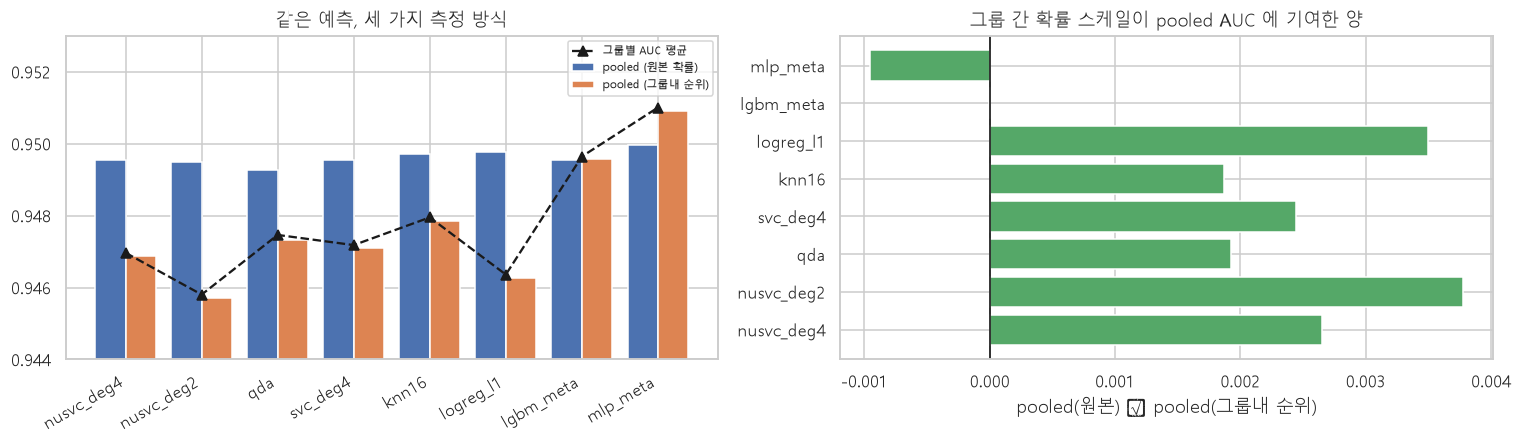

그룹내 순위로 바꾼 pooled AUC 는 그룹별 AUC 평균과 거의 같다:
  차이 평균 0.00009

앙상블에도 같은 조작을 적용하면:


  8열 단순평균 (원본 확률)   : 0.949605
  8열 단순평균 (그룹내 순위) : 0.946690


In [5]:
# 그룹별 행 인덱스를 미리 계산 (argsort + searchsorted 로 한 번에)
order = np.argsort(magic, kind="stable")
bounds = np.searchsorted(magic[order], np.arange(513))
GROUP_SLICES = [order[bounds[m]:bounds[m + 1]] for m in range(512)]


def rank_within_group(values):
    """그룹 안에서만 순위로 바꾼다 (그룹 간 스케일 정보 제거).

    각 그룹의 값을 0~1 사이 순위로 바꾸므로, 그룹 내 순서는 완전히 보존되고
    '어느 그룹의 예측이 더 극단적인가' 라는 정보만 사라진다.
    """
    out = np.empty(len(values))
    for idx in GROUP_SLICES:
        out[idx] = stats.rankdata(values[idx]) / len(idx)
    return out


rows = []
for col in ALL_COLS:
    v = oof[col].to_numpy()
    rows.append({
        "모델": col,
        "pooled AUC (원본)": roc_auc_score(y, v),
        "pooled AUC (그룹내 순위)": roc_auc_score(y, rank_within_group(v)),
        "그룹별 AUC 평균": np.mean([roc_auc_score(y[idx], v[idx]) for idx in GROUP_SLICES]),
    })
scale_df = pd.DataFrame(rows).set_index("모델")
scale_df["스케일 기여"] = scale_df["pooled AUC (원본)"] - scale_df["pooled AUC (그룹내 순위)"]
display(scale_df.round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(scale_df))
axes[0].bar(x - 0.2, scale_df["pooled AUC (원본)"], 0.4, label="pooled (원본 확률)")
axes[0].bar(x + 0.2, scale_df["pooled AUC (그룹내 순위)"], 0.4, label="pooled (그룹내 순위)")
axes[0].plot(x, scale_df["그룹별 AUC 평균"], "k^--", ms=6, label="그룹별 AUC 평균")
axes[0].set_xticks(x)
axes[0].set_xticklabels(scale_df.index, rotation=30, ha="right")
axes[0].set_ylim(0.944, 0.953)
axes[0].set_title("같은 예측, 세 가지 측정 방식")
axes[0].legend(fontsize=7)

axes[1].barh(scale_df.index, scale_df["스케일 기여"], color="#55a868")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("그룹 간 확률 스케일이 pooled AUC 에 기여한 양")
axes[1].set_xlabel("pooled(원본) − pooled(그룹내 순위)")
plt.tight_layout()
plt.show()

print("그룹내 순위로 바꾼 pooled AUC 는 그룹별 AUC 평균과 거의 같다:")
print(f"  차이 평균 {(scale_df['pooled AUC (그룹내 순위)'] - scale_df['그룹별 AUC 평균']).abs().mean():.5f}")
print()
print("앙상블에도 같은 조작을 적용하면:")
M = oof[ALL_COLS].to_numpy()
M_rank = np.column_stack([rank_within_group(M[:, j]) for j in range(M.shape[1])])
print(f"  8열 단순평균 (원본 확률)   : {roc_auc_score(y, M.mean(axis=1)):.6f}")
print(f"  8열 단순평균 (그룹내 순위) : {roc_auc_score(y, M_rank.mean(axis=1)):.6f}")

> ### 관찰 — 그룹 간 확률 스케일에는 버릴 수 없는 정보가 있다
>
> 모든 level-1 모델에서 **pooled(원본) > pooled(그룹내 순위) ≈ 그룹별 AUC 평균** 이다.
> 순위 정규화를 하면 점수가 떨어진다. 즉 **지워진 정보가 유용했다**는 뜻이다.
>
> ### 왜 그룹 간 스케일이 정보인가
>
> 어떤 그룹은 다른 그룹보다 분류가 잘 된다.
> 잘 되는 그룹의 샘플은 예측이 0.99 / 0.01 처럼 **극단**으로 가고,
> 애매한 그룹의 샘플은 0.6 / 0.4 근처에 머문다.
>
> 이제 262,144행을 한 줄로 세워 순위를 매긴다고 생각해 보자.
> "0.99" 인 샘플은 "0.6" 인 샘플보다 **실제로 양성일 가능성이 높다** — 그룹이 다르더라도.
> **확률의 절대값이 그 예측의 신뢰도를 담고 있는 것이다.**
> 순위 정규화는 이 정보를 통째로 버린다.
>
> ### 1절 수수께끼의 답 — logreg_l1 은 왜 2위인가
>
> | | 그룹별 AUC | pooled AUC |
> |---|---|---|
> | `logreg_l1` | **0.94636 (꼴찌)** | **0.94977 (2위)** |
> | `qda` | 0.94746 | 0.94926 |
>
> logreg 는 **그룹 안에서 순위를 매기는 능력은 가장 나쁘다.**
> 하지만 확률을 0.07~0.94 의 좁은 구간에 **압축해서** 내놓기 때문에,
> 512개 그룹의 점수가 **서로 비교 가능하다.**
> 반면 QDA 는 그룹마다 0/1 로 포화되어서, 한 줄로 모으면 순위가 뒤죽박죽이 된다.
>
> **즉 pooled 지표에서는 "그룹 내 판별력"과 "그룹 간 비교 가능성"이 둘 다 필요하고,
> logreg 는 두 번째를 압도적으로 잘한다.**
>
> ### 실무적 함의 3가지
>
> 1. **순위 평균(rank averaging) 앙상블을 쓰면 안 된다.**
>    캐글에서 흔히 쓰는 기법이지만, 여기서는 스스로 정보를 버리는 셈이다
>    (실제로 8열 순위평균은 0.9467 로 확률평균 0.9496 보다 낮다)
> 2. **모델을 그룹별 AUC 로만 평가하면 logreg 같은 모델의 가치를 놓친다**
> 3. **대회 지표와 같은 방식으로 평가하라** — 여기서는 pooled
>
> > **초보자에게** — "CV 점수를 어떻게 계산할 것인가"는 사소해 보이지만
> > **모델 선택 자체를 바꿔 버린다.** 평가 방식이 대회 지표와 다르면
> > 엉뚱한 모델을 고르게 된다.

## 4. 그룹별로 잘하는 모델이 다른가?

**무엇을 하나** — 512개 그룹 각각에서 모델별 AUC 를 재고,
"그룹마다 가장 좋은 모델을 골라 쓴다면" 얼마나 오를지 계산한다.

**용어 — 오라클(oracle)**
**정답을 미리 보고** 최선의 선택을 했을 때의 성능. 실전에서는 달성 불가능한 **상한선**이다.
"이 전략을 완벽하게 실행해도 이 정도밖에 못 얻는다"를 알려 주므로,
**전략을 시도할 가치가 있는지 판단하는 데 유용하다.**

**왜 상한선을 먼저 재나** — 그룹별 모델 선택은 구현이 복잡하다.
며칠 걸려 만들었는데 상한이 +0.001 이었다면 시작하지 말았어야 한다.
**어려운 작업을 시작하기 전에 오라클로 상한을 재 보는 습관**은 시간을 크게 아껴 준다.

**공정한 비교를 위한 주의** — 그룹마다 다른 모델을 쓰면 확률 스케일이 섞인다.
3절에서 본 대로 그러면 pooled AUC 가 왜곡되므로,
**양쪽 모두 그룹내 순위 척도로 맞춰서** 비교한다.

**기대 (02 노트북의 결론에 비추어)** — [02 노트북](02_magic_group_structure.ipynb) 3절에서
그룹별 AUC 차이의 83%가 측정 오차임을 확인했다. 그렇다면 오라클의 이득도 작아야 한다.

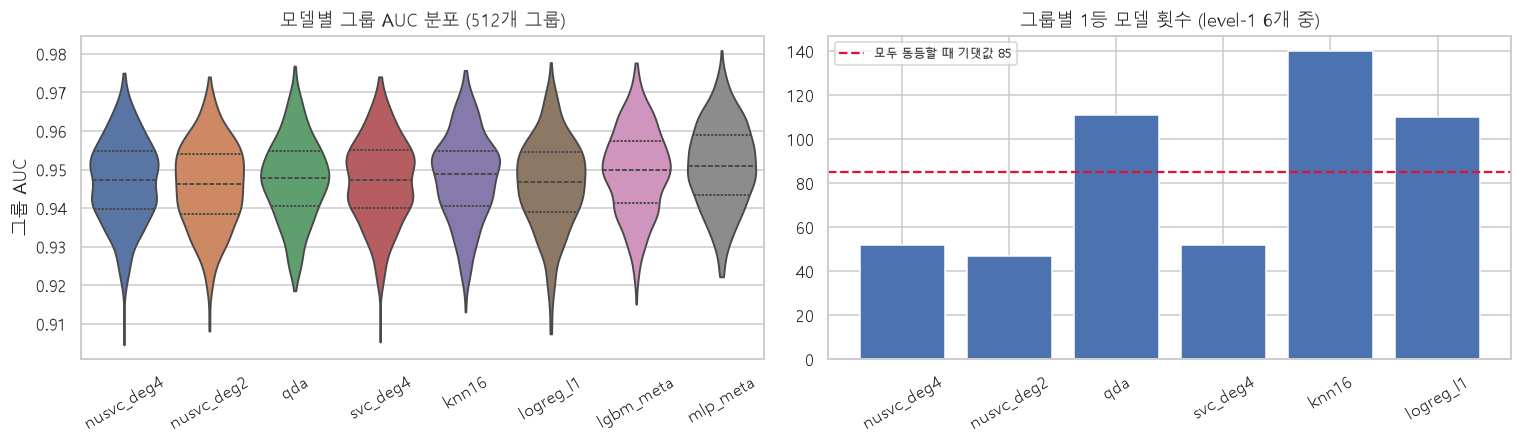

그룹 AUC 평균:
mlp_meta      0.95100
lgbm_meta     0.94964
knn16         0.94795
qda           0.94746
svc_deg4      0.94718
nusvc_deg4    0.94697
logreg_l1     0.94636
nusvc_deg2    0.94580

그룹 안에서 최고-최저 모델 AUC 차: 평균 0.0089
logreg_l1 를 뺀 5개 모델만의 최고-최저 차: 0.0070


In [6]:
group_auc = np.zeros((512, len(ALL_COLS)))
for m in range(512):
    sel = magic == m
    ys = y[sel]
    for j, col in enumerate(ALL_COLS):
        group_auc[m, j] = roc_auc_score(ys, oof[col].to_numpy()[sel])
group_auc_df = pd.DataFrame(group_auc, columns=ALL_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
sns.violinplot(data=group_auc_df, ax=axes[0], inner="quartile", cut=0)
axes[0].set_title("모델별 그룹 AUC 분포 (512개 그룹)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("그룹 AUC")

# 각 그룹에서 1등을 한 모델을 세어 본다
winner = group_auc_df[MODEL_NAMES].to_numpy().argmax(axis=1)
counts = pd.Series(np.bincount(winner, minlength=len(MODEL_NAMES)), index=MODEL_NAMES)
axes[1].bar(counts.index, counts.to_numpy(), color="#4c72b0")
axes[1].axhline(512 / len(MODEL_NAMES), color="crimson", ls="--",
                label=f"모두 동등할 때 기댓값 {512 / len(MODEL_NAMES):.0f}")
axes[1].set_title("그룹별 1등 모델 횟수 (level-1 6개 중)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("그룹 AUC 평균:")
print(group_auc_df.mean().round(5).sort_values(ascending=False).to_string())
print()
best_gap = (group_auc_df[MODEL_NAMES].max(axis=1) - group_auc_df[MODEL_NAMES].min(axis=1))
print(f"그룹 안에서 최고-최저 모델 AUC 차: 평균 {best_gap.mean():.4f}")
print(f"logreg_l1 를 뺀 5개 모델만의 최고-최저 차: "
      f"{(group_auc_df[[c for c in MODEL_NAMES if c != 'logreg_l1']].max(axis=1) - group_auc_df[[c for c in MODEL_NAMES if c != 'logreg_l1']].min(axis=1)).mean():.4f}")

In [7]:
# 오라클: 각 그룹에서 '정답을 보고' 가장 좋은 모델을 골라 쓴다
oracle = np.zeros(len(y))
for m, idx in enumerate(GROUP_SLICES):
    best_col = ALL_COLS[int(group_auc[m, :len(MODEL_NAMES)].argmax())]
    oracle[idx] = stats.rankdata(oof[best_col].to_numpy()[idx]) / len(idx)
oracle_auc = roc_auc_score(y, oracle)

# 공정한 비교: 단일 모델도 같은 '그룹내 순위' 척도로 변환해서 잰다
rank_pooled = {c: roc_auc_score(y, rank_within_group(oof[c].to_numpy())) for c in MODEL_NAMES}
best_rank_model = max(rank_pooled, key=rank_pooled.get)
best_single = auc_table[MODEL_NAMES].idxmax()

print("[그룹내 순위 척도 — 공정 비교]")
print(f"  항상 {best_rank_model} 사용         : {rank_pooled[best_rank_model]:.5f}")
print(f"  그룹별 최고 모델 선택 (오라클)  : {oracle_auc:.5f}")
print(f"  오라클이 얻는 상한             : {oracle_auc - rank_pooled[best_rank_model]:+.5f}")
print()
print("[참고] 원본 확률 척도에서의 최고 단일 모델")
print(f"  {best_single}: {auc_table[best_single]:.5f}")
print()
print("오라클은 정답을 보고 고른 값이라 실전에서 달성 불가능한 상한이다.")
print("그 상한조차 작다면 그룹별 모델 선택은 잡음을 좇는 일이 된다.")

[그룹내 순위 척도 — 공정 비교]
  항상 knn16 사용         : 0.94784
  그룹별 최고 모델 선택 (오라클)  : 0.95123
  오라클이 얻는 상한             : +0.00340

[참고] 원본 확률 척도에서의 최고 단일 모델
  logreg_l1: 0.94977

오라클은 정답을 보고 고른 값이라 실전에서 달성 불가능한 상한이다.
그 상한조차 작다면 그룹별 모델 선택은 잡음을 좇는 일이 된다.


> **관찰 — 오라클의 상한이 +0.0034 뿐이다.**
>
> 이 +0.0034 는 **정답을 컨닝했을 때의 값**이다. 실전에서는 어느 모델이 좋은지 모르므로,
> CV 로 골라야 하는데 그 CV 자체가 512행에서 잰 잡음투성이 값이다
> ([02 노트북](02_magic_group_structure.ipynb) 3절: 그룹별 AUC 편차의 83%가 측정 오차).
>
> **컨닝해도 +0.0034 인데, 잡음을 보고 고르면 오히려 손해를 볼 가능성이 높다.**
>
> 1등 모델 횟수 그래프도 특정 모델로 쏠려 있지 않다 — 그룹마다 1등이 바뀌는 것은
> 실력 차이가 아니라 **동전 던지기에 가깝다.**
>
> ### 결론: 그룹별 모델 선택은 하지 말 것
> 02 노트북의 예측이 실제 데이터로 확인되었다. **512개 그룹에 같은 파이프라인**을 쓰는 것이 옳다.

## 5. 가중 앙상블 — 단순 평균을 이길 수 있는가?

**무엇을 하나** — 8개 예측의 가중치를 학습시켜 단순 평균보다 나은지 본다.

**왜 하나** — baseline 은 8열을 **단순 평균**한다. 모델마다 성능이 다른데
같은 가중치를 주는 게 최선일 리 없어 보인다. 실제로 그런지 확인한다.

### ⚠️ 여기서 초보자가 반드시 빠지는 함정

```python
# ❌ 잘못된 방법
w = 가중치_최적화(oof, y)              # OOF 전체로 가중치를 학습
score = roc_auc_score(y, oof @ w)      # 같은 OOF 로 평가
# -> 항상 단순 평균보다 높게 나온다. 당연하다. 그 데이터에 맞춘 가중치니까.
```

**같은 데이터로 학습하고 같은 데이터로 평가하면 반드시 좋아 보인다.**
이건 성능이 아니라 **과적합의 크기**를 잰 것이다.

```
✅ 올바른 방법 (아래 코드)
데이터를 절반으로 나눠서:
  A 절반으로 가중치 학습 -> B 절반에서 평가
  B 절반으로 가중치 학습 -> A 절반에서 평가
  두 결과를 평균
```

### 판정 기준 두 가지

점수만 보지 말고 **가중치가 재현되는지**도 봐야 한다.

1. **홀드아웃 점수** — 단순 평균보다 높은가?
2. **가중치 안정성** — A 에서 학습한 가중치와 B 에서 학습한 가중치가 비슷한가?

2번이 더 중요하다. **가중치가 fold 마다 완전히 달라진다면**,
그건 신호가 아니라 **각 fold 의 잡음에 맞춘 것**이다.
그런 가중치는 test 에서 작동할 이유가 없다.

> 이 규모(262,144행)에서 AUC 차이 **0.0001 미만은 잡음**으로 본다.

In [8]:
from scipy.optimize import minimize

P = oof[ALL_COLS].to_numpy()                              # 확률 그대로
R = np.apply_along_axis(stats.rankdata, 0, P) / len(P)    # 전체 순위로 정규화한 버전

rng = np.random.default_rng(0)
half = rng.permutation(len(y))
# 양방향 교차: (앞절반 학습 -> 뒷절반 평가), (뒷절반 학습 -> 앞절반 평가)
folds = [(half[: len(y) // 2], half[len(y) // 2:]), (half[len(y) // 2:], half[: len(y) // 2])]


def fit_weights(mat, idx):
    """AUC 를 최대화하는 비음수 가중치를 찾는다 (Nelder-Mead).

    AUC 는 미분 불가능한 지표라 경사하강법을 쓸 수 없다.
    Nelder-Mead 는 미분 없이 함수값만으로 최적점을 찾는 방법이다.
    """
    def neg_auc(w):
        w = np.abs(w)                      # 음수 가중치를 막는다
        if w.sum() == 0:
            return 0.0
        return -roc_auc_score(y[idx], mat[idx] @ (w / w.sum()))
    x0 = np.ones(mat.shape[1]) / mat.shape[1]      # 단순 평균에서 출발
    res = minimize(neg_auc, x0, method="Nelder-Mead",
                   options={"maxiter": 600, "xatol": 1e-4, "fatol": 1e-7})
    w = np.abs(res.x)
    return w / w.sum()


schemes = {}
for label, mat in (("확률", P), ("순위", R)):
    schemes[f"단순평균 ({label})"] = np.array([
        roc_auc_score(y[te], mat[te].mean(axis=1)) for _, te in folds
    ]).mean()

weights_prob, weights_rank = [], []
for label, mat, store in (("확률", P, weights_prob), ("순위", R, weights_rank)):
    scores = []
    for tr, te in folds:
        w = fit_weights(mat, tr)       # tr 로 학습
        store.append(w)
        scores.append(roc_auc_score(y[te], mat[te] @ w))   # te 로 평가 (누수 없음)
    schemes[f"가중평균 ({label}, 홀드아웃 평가)"] = np.mean(scores)

# 메타 모델 2개를 빼고 level-1 6개만 평균하면 어떨까?
schemes["level-1 6개만 단순평균 (확률)"] = np.array([
    roc_auc_score(y[te], P[te][:, :len(MODEL_NAMES)].mean(axis=1)) for _, te in folds
]).mean()

result = pd.Series(schemes).sort_values(ascending=False)
print("절반 학습 / 절반 평가, 양방향 평균 AUC:")
print(result.round(6).to_string())
print()
print(f"baseline 최종(8열 단순평균) 전체 OOF AUC: {metrics['final_auc']:.6f}")

절반 학습 / 절반 평가, 양방향 평균 AUC:
단순평균 (확률)                0.949603
level-1 6개만 단순평균 (확률)    0.949603
가중평균 (순위, 홀드아웃 평가)       0.949594
가중평균 (확률, 홀드아웃 평가)       0.949575
단순평균 (순위)                0.949423

baseline 최종(8열 단순평균) 전체 OOF AUC: 0.949605


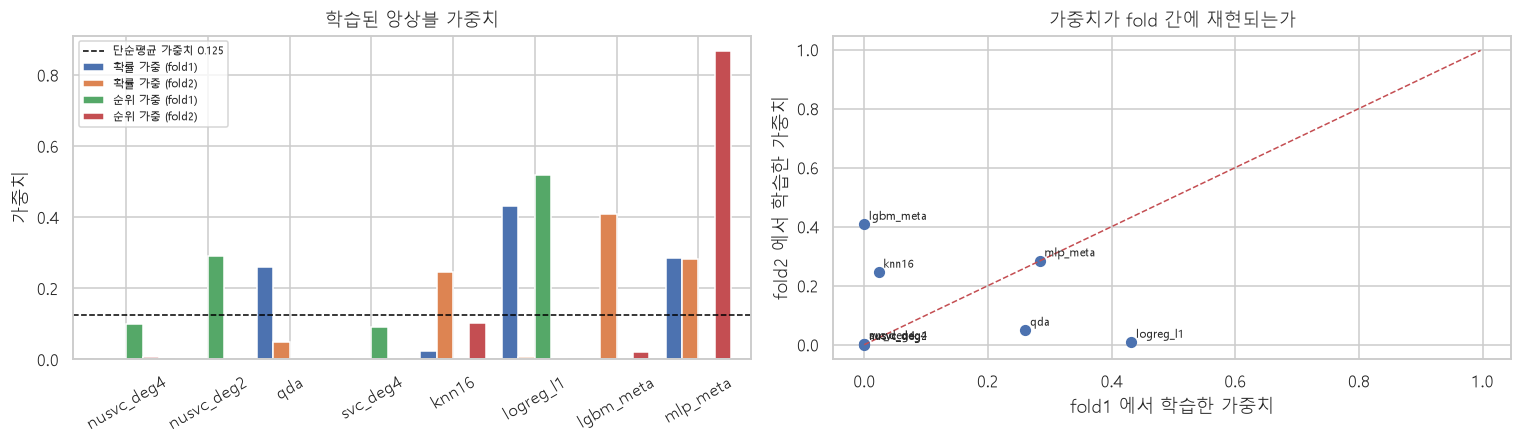

두 fold 에서 학습한 확률 가중치의 상관: -0.115
            확률 가중 (fold1)  확률 가중 (fold2)  순위 가중 (fold1)  순위 가중 (fold2)
nusvc_deg4         0.0000         0.0032         0.0995         0.0075
nusvc_deg2         0.0005         0.0004         0.2922         0.0000
qda                0.2603         0.0487         0.0000         0.0002
svc_deg4           0.0000         0.0031         0.0910         0.0001
knn16              0.0234         0.2454         0.0000         0.1033
logreg_l1          0.4320         0.0079         0.5173         0.0000
lgbm_meta          0.0000         0.4076         0.0000         0.0220
mlp_meta           0.2838         0.2837         0.0000         0.8668


In [9]:
w_df = pd.DataFrame(
    {"확률 가중 (fold1)": weights_prob[0], "확률 가중 (fold2)": weights_prob[1],
     "순위 가중 (fold1)": weights_rank[0], "순위 가중 (fold2)": weights_rank[1]},
    index=ALL_COLS,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
w_df.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].axhline(1 / len(ALL_COLS), color="black", ls="--", lw=1,
                label=f"단순평균 가중치 {1 / len(ALL_COLS):.3f}")
axes[0].set_title("학습된 앙상블 가중치")
axes[0].set_ylabel("가중치")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=7)

# 두 fold 에서 학습한 가중치를 산점도로: 대각선 위에 있으면 재현되는 것
axes[1].scatter(w_df["확률 가중 (fold1)"], w_df["확률 가중 (fold2)"], s=40)
for name, row in w_df.iterrows():
    axes[1].annotate(name, (row["확률 가중 (fold1)"], row["확률 가중 (fold2)"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
lims = [0, max(w_df.max()) * 1.15]
axes[1].plot(lims, lims, "r--", lw=1)
axes[1].set_xlabel("fold1 에서 학습한 가중치")
axes[1].set_ylabel("fold2 에서 학습한 가중치")
axes[1].set_title("가중치가 fold 간에 재현되는가")
plt.tight_layout()
plt.show()

corr_w = np.corrcoef(w_df["확률 가중 (fold1)"], w_df["확률 가중 (fold2)"])[0, 1]
print(f"두 fold 에서 학습한 확률 가중치의 상관: {corr_w:.3f}")
print(w_df.round(4).to_string())

> ### 관찰 — 가중치는 신호가 아니라 잡음을 맞추고 있다
>
> **점수:** 홀드아웃 가중평균 0.949575 vs 단순평균 0.949603 — 차이 −0.00003 으로 **사실상 동률**이다.
> 이 규모에서 0.00003 은 잡음이므로 "낮다"고 단정할 수도 없다. 정확히는 **"이득이 없다"** 이다.
>
> **더 결정적인 것은 가중치의 불안정성이다.** 두 fold 에서 학습한 가중치의 상관이 **−0.115**.
> 산점도의 점들이 대각선과 아무 관계가 없다.
>
> | 모델 | fold1 가중치 | fold2 가중치 |
> |---|---|---|
> | `qda` | 0.26 | 0.05 |
> | `logreg_l1` | **0.43** | 0.01 |
> | `lgbm_meta` | 0.00 | **0.41** |
>
> fold1 에서는 logreg 가 가장 중요하다고 하고, fold2 에서는 lgbm 이라고 한다.
> **131,072행으로 학습했는데도 이 정도로 흔들린다면**, 그 가중치는 믿을 수 없다.
>
> ### 왜 이런 일이 일어나나
> 1절에서 본 것처럼 모델들의 순위상관이 0.89~0.99 다.
> **거의 같은 예측에 가중치를 배분하는 문제**는 답이 하나로 정해지지 않는다
> (통계에서 말하는 **다중공선성**). A 에 0.4 를 주든 B 에 0.4 를 주든 결과가 비슷하니,
> 최적화 알고리즘은 그때그때 잡음을 따라 아무 데나 몰아준다.
>
> ### 결론
> **단순 평균이 정답이다.** 그리고 이것은 baseline 의 게으름이 아니라
> **모델들이 서로 너무 비슷하다는 사실의 결과**다.
> 앙상블을 개선하려면 가중치가 아니라 **모델 다양성**을 손봐야 한다.

## 6. 어디에서 틀리는가?

**무엇을 하나** — 최종 예측이 크게 틀린 샘플들의 특성을 본다.

**왜 하나** — 오류 분석(error analysis)은 다음에 무엇을 할지 정하는 데 쓰인다.
오류가 **특정 그룹에 몰려 있다면** 그 그룹을 따로 손볼 수 있고,
**고르게 퍼져 있다면** 구조적인 한계라는 뜻이다.

**용어 — 확신 오답**
`p > 0.9` 인데 실제로는 0이거나, `p < 0.1` 인데 실제로는 1인 샘플.
모델이 **틀렸다는 것조차 모르는** 경우라 가장 위험하다.
(pseudo labeling 을 할 때 이런 샘플이 가짜 라벨로 들어가면 오류가 증폭된다)

전체 OOF AUC: 0.94960
확신했는데 틀린 샘플: 8,409개 (3.21%)


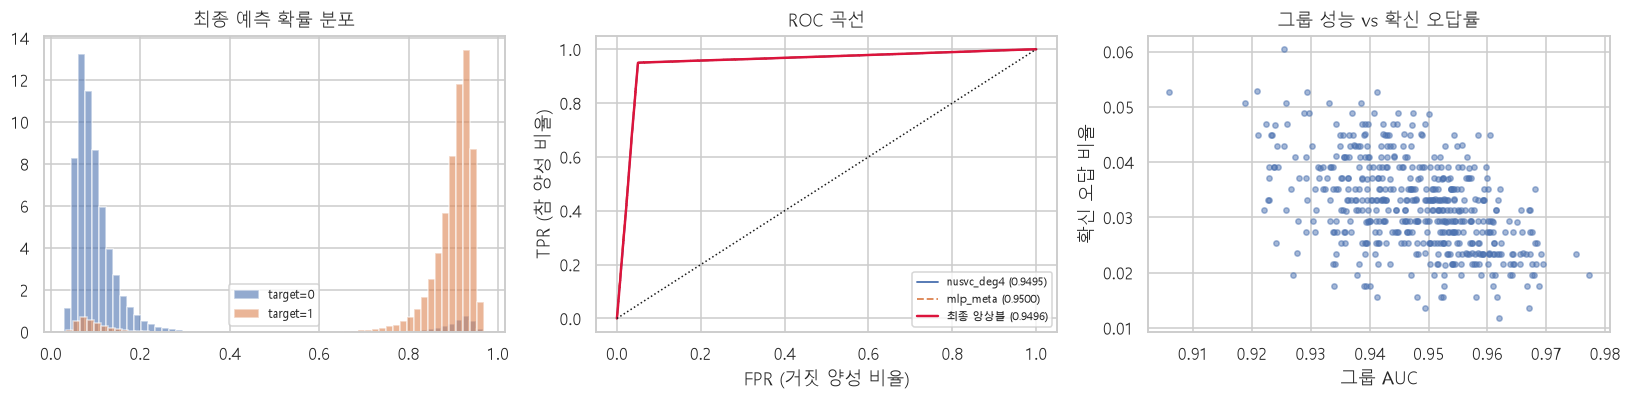


가장 어려운 5개 그룹:
 magic  group_auc  conf_wrong_rate
    92     0.9059           0.0527
    89     0.9188           0.0508
   218     0.9209           0.0528
   388     0.9210           0.0449
   217     0.9220           0.0312


In [10]:
final_pred = oof_final.mean(axis=1)     # baseline 의 최종 예측 = 8열 단순 평균
error = np.abs(y - final_pred)
conf_wrong = ((final_pred > 0.9) & (y == 0)) | ((final_pred < 0.1) & (y == 1))

print(f"전체 OOF AUC: {roc_auc_score(y, final_pred):.5f}")
print(f"확신했는데 틀린 샘플: {conf_wrong.sum():,}개 ({conf_wrong.mean():.2%})")

group_err = pd.DataFrame({
    "magic": np.arange(512),
    "group_auc": [roc_auc_score(y[magic == m], final_pred[magic == m]) for m in range(512)],
    "conf_wrong_rate": [conf_wrong[magic == m].mean() for m in range(512)],
})

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(final_pred[y == 0], bins=60, alpha=0.6, label="target=0", density=True)
axes[0].hist(final_pred[y == 1], bins=60, alpha=0.6, label="target=1", density=True)
axes[0].set_title("최종 예측 확률 분포")
axes[0].legend(fontsize=8)

for col, style in ((MODEL_NAMES[0], "-"), ("mlp_meta", "--")):
    fpr, tpr, _ = roc_curve(y, oof[col])
    axes[1].plot(fpr, tpr, style, lw=1.2, label=f"{col} ({auc_table[col]:.4f})")
fpr, tpr, _ = roc_curve(y, final_pred)
axes[1].plot(fpr, tpr, lw=1.6, color="crimson", label=f"최종 앙상블 ({roc_auc_score(y, final_pred):.4f})")
axes[1].plot([0, 1], [0, 1], "k:", lw=1)
axes[1].set_xlabel("FPR (거짓 양성 비율)")
axes[1].set_ylabel("TPR (참 양성 비율)")
axes[1].set_title("ROC 곡선")
axes[1].legend(fontsize=7)

axes[2].scatter(group_err["group_auc"], group_err["conf_wrong_rate"], s=12, alpha=0.5)
axes[2].set_xlabel("그룹 AUC")
axes[2].set_ylabel("확신 오답 비율")
axes[2].set_title("그룹 성능 vs 확신 오답률")
plt.tight_layout()
plt.show()

print()
print("가장 어려운 5개 그룹:")
print(group_err.nsmallest(5, "group_auc").round(4).to_string(index=False))

> **관찰.** 확신 오답이 **3.21%** (8,409개) 있다. 그룹 AUC 가 낮을수록 확신 오답률이 높다는
> 자연스러운 관계가 보이지만, 특정 그룹에 극단적으로 몰려 있지는 않다.
>
> **pseudo labeling 에 시사하는 점:** [03 노트북](03_feature_engineering.ipynb) 7절에서
> 확신 구간(p>0.9)의 test 예측을 가짜 라벨로 썼다. 그 중 약 3% 는 **틀린 라벨**이라는 뜻이다.
> 그럼에도 이득이 났다는 것은, **표본이 늘어나는 이득이 3% 오염보다 크다**는 의미다.
> (다만 pseudo labeling 을 반복하면 이 오염이 누적될 수 있으니 주의해야 한다)
>
> "가장 어려운 5개 그룹"은 참고용으로만 보자.
> [02 노트북](02_magic_group_structure.ipynb) 3절에서 확인했듯 이 순위의 대부분은 측정 오차다.

## 7. 종합

In [11]:
summary = pd.DataFrame([
    ["최고 단일 모델", best_single, round(auc_table[best_single], 5)],
    ["최저 단일 모델", auc_table[MODEL_NAMES].idxmin(), round(auc_table[MODEL_NAMES].min(), 5)],
    ["최고 메타 모델", auc_table[["lgbm_meta", "mlp_meta"]].idxmax(),
     round(auc_table[["lgbm_meta", "mlp_meta"]].max(), 5)],
    ["baseline 최종 (8열 단순평균)", "-", round(metrics["final_auc"], 5)],
    ["단순 평균 (홀드아웃 평가)", "확률", round(schemes["단순평균 (확률)"], 5)],
    ["가중 앙상블 (홀드아웃 평가)", "확률 가중",
     round(schemes["가중평균 (확률, 홀드아웃 평가)"], 5)],
    ["그룹별 최고 모델 (오라클, 순위 척도)", "-", round(oracle_auc, 5)],
], columns=["구성", "모델", "AUC"])
display(summary)

,구성,모델,AUC
0,최고 단일 모델,logreg_l1,0.94977
1,최저 단일 모델,qda,0.94926
2,최고 메타 모델,mlp_meta,0.94996
3,baseline 최종 (8열 단순평균),-,0.94960
4,단순 평균 (홀드아웃 평가),확률,0.94960
5,가중 앙상블 (홀드아웃 평가),확률 가중,0.94957
6,"그룹별 최고 모델 (오라클, 순위 척도)",-,0.95123


## 8. 결론

| 질문 | 결론 |
|---|---|
| 모델 다양성 | level-1 6개 모델의 순위상관 **0.89~0.99** — 대체로 같은 실수를 한다. 앙상블 이득이 없는 근본 원인 |
| **평가 척도** | **pooled AUC > 그룹별 AUC 평균.** 그룹 간 확률 스케일 자체가 정보다. 따라서 **순위 평균은 쓰면 안 되고**, 모델 평가도 pooled 로 해야 한다 |
| 의외의 결과 | `logreg_l1` 은 그룹 안에서 최하위지만 pooled 로는 2위 — 확률이 압축돼 있어 그룹 간 비교 가능성이 높기 때문 |
| 그룹별 모델 선택 | 정답을 보고 고르는 오라클조차 상한이 +0.0034 — 잡음을 좇는 일 |
| 가중 앙상블 | 홀드아웃에서 이득 없음(−0.00003). 두 fold 가중치 상관 **−0.115** 로 재현되지 않는다 |
| 다음 단계 | 앙상블 쪽은 짜낼 것이 없다. [03](03_feature_engineering.ipynb) 의 **pseudo labeling** 이 훨씬 큰 여지를 갖는다 |

### 이 노트북에서 배운 진단 원칙 4가지

1. **OOF 예측을 저장하라** — 재학습 없이 앙상블·오류 분석을 전부 할 수 있다
2. **앙상블 전에 상관을 재라** — 모델 개수가 아니라 다양성이 이득을 만든다
3. **평가 방식을 대회 지표와 일치시켜라** — pooled 냐 그룹별이냐가 모델 선택을 바꾼다
4. **점수보다 안정성을 보라** — 가중치가 fold 간에 재현되지 않으면 그 점수는 의미가 없다

### 직접 해보기

- 3절의 `rank_within_group` 을 **그룹별 표준화(z-score)** 로 바꿔 보라
  (`(v - mean) / std`). 순위 정규화보다 스케일 정보를 덜 지우므로 결과가 다를 것이다.
  **어느 정도의 정보가 '스케일'에 담겨 있는지** 더 정밀하게 잴 수 있다
- 5절의 `fit_weights` 를 **level-1 6개 모델에만** 적용해 보라. 메타 모델을 빼면 가중치가 안정되는가?
- 1절에서 상관이 가장 낮은 두 모델(`nusvc_deg4`, `logreg_l1`)**만** 평균내면 어떻게 되는가?
  8개를 다 쓰는 것보다 나은가? (다양성 가설을 직접 시험하는 실험이다)
- 6절의 확신 오답 8,409개가 **어떤 그룹·어떤 예측 구간**에 몰려 있는지 더 파고들어 보라

### 시리즈를 마치며

| 노트북 | 핵심 발견 |
|---|---|
| [01](01_eda_report.ipynb) | 신호가 안 보이면 **보는 단위**를 의심하라 — magic 컬럼 발견 |
| [02](02_magic_group_structure.ipynb) | 관측값은 **기준선·측정 오차와 비교**해야 의미가 생긴다 |
| [03](03_feature_engineering.ipynb) | **대응 비교와 신뢰구간**으로 재면 baseline 의 절반은 효과가 없다 |
| **04 (지금)** | **평가 방식 자체**가 모델 선택을 바꾼다 |

네 노트북 모두에서 반복된 교훈이 하나 있다.
**"숫자 하나만 보고 판단하지 말고, 항상 비교 대상과 잡음 크기를 함께 보라."**